## Optimizers Comparison

### Introduction

The goal of this notebook is to perform a small research of behave model with different optimizers. We need to understand why certain optimizer perform better than other in some situations.

### Theoretical Background

In supervised learning, we want to minimize: $$L(\theta) = \frac{1}{N}\sum_{i=1}^{n}l(f_{\theta}(x_i), y_i),$$
where $\theta$ - model parameters, $f_{\theta}$ - model, $l$ - loss function, $N$ - data size.

Optimizers must deal with several fundamental difficulties such as *High-Dimensional Parameter Space*, *Non-Convexity*, *Exploding and Vanishing Gradients*, etc.

The core algorithm of finding best parameters is to use *Gradient Descent*: $$\theta_{t+1} = \theta_{t} - \eta\nabla\hat{L}(\theta_{t}),$$
which is computes the gradient using entire dataset.


In here we see into four most popular optimizers of *GD*. Let's briefly describe them.

 - **Stochastic Gradient Descent(SGD)** <br /> Update Rule: $$\theta_{t+1} = \theta_{t} - \eta\nabla{l(f_{\theta}(x_i), y_i))}$$
        Or most commonly used a mini-batch SGD: $$\theta_{t+1} = \theta_{t} - \eta\hat{L}(\theta_{t}),$$
where $$\hat{L}(\theta_{t}) = \frac{1}{B}\sum_{i \in batch}{l(f_{\theta(x_i)}, y_i)}.$$

 - **Gradient Descent + Momentum** <br />
 Velocity update: $$v_t = \beta{v_{t-1}} + \nabla\hat{L}(\theta_t),$$
 Parameter update: $$\theta_{t+1} = \theta_t - \eta{v_t}$$
 Where: $\beta \in [0, 1]$ controls memory of past gradients. <br />
 
*Intuition*: Like a rolling boll. Builds velocity in consistent directions, reduces oscillations in steep directions, accelerates in flat directions.

 - **RMSProp** <br />
 Running average of squared gradients: $$s_t = \rho{s_{t-1}} + (1 - \rho){g_t}^2$$
 Update: $$\theta_{t+1} = \theta_{t} - \frac{\eta}{\sqrt{s_t} + \epsilon}g_t$$
 Where: $g_t = \nabla\hat{L}(\theta_t), \rho = $ decay rate. <br />

*Intuition*: If a parameter consistently has large gradients -> Reduce its step size. If gradients are small -> Increase effective step size.

 - **Adam** <br />
 Adam combines *Momentum* + *RMSProp*: <br />
 Step 1: First Moment $$m_t = \beta_1{m_{t-1}} + (1 - \beta_1)g_t$$
 Step 2: Second Moment $$v_t = \beta_2{v_{t-1}} + (1 - \beta_2){g_t}^2$$
 Bias correction: $$\hat{m_t} = \frac{m_t}{1-{\beta_1}^t}$$
 $$\hat{v_t} = \frac{v_t}{1-{\beta_2}^t}$$
 Final update: $$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v_t} + \epsilon}}\hat{m_t}$$

*Intuition*: Smooths gradients (momentum), adapts step size per parameter, corrects early bias.

This project empirically compares these optimizers in terms of convergence speed, stability, and generalization performance under controlled experimental conditions.

### Experiment Setup

I decided to choose a MLP model and MNIST dataset as the most easy to understand setup.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [5]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.model(x)

In [7]:
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight)
            nn.init.zeros_(m.bias)

In [8]:
criterion = nn.CrossEntropyLoss()

In [9]:
def get_optimizer(name, model, lr):
    name = name.lower()

    if name == "sgd":
        return optim.SGD(model.parameters(), lr=lr)
    elif name == "momentum":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=lr)
    elif name == "adam":
        return optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {name}")
    

In [12]:
def traininig_loop(model, optimizer, epoches, device="cpu"):

    model.to(device)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in tqdm(range(epoches)):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_dataloader:
            
            images = images.to(device) 
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_dataloader)
        train_acc = correct / total

        model.eval()
        
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_dataloader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(test_dataloader)
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
    
    return history

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
epoches = 20
lr = 0.01
optimizers = ["SGD", "MOMENTUM", "RMSprop", "Adam"]

all_histories = {}

for opt_name in optimizers:

    torch.manual_seed(42)
    model = MLP()
    initialize_weights(model)

    optimizer = get_optimizer(opt_name, model, lr=lr)

    history = traininig_loop(
        model=model,
        optimizer=optimizer,
        epoches=epoches,
        device=device
    )

    all_histories[opt_name] = history



100%|██████████| 20/20 [02:57<00:00,  8.85s/it]


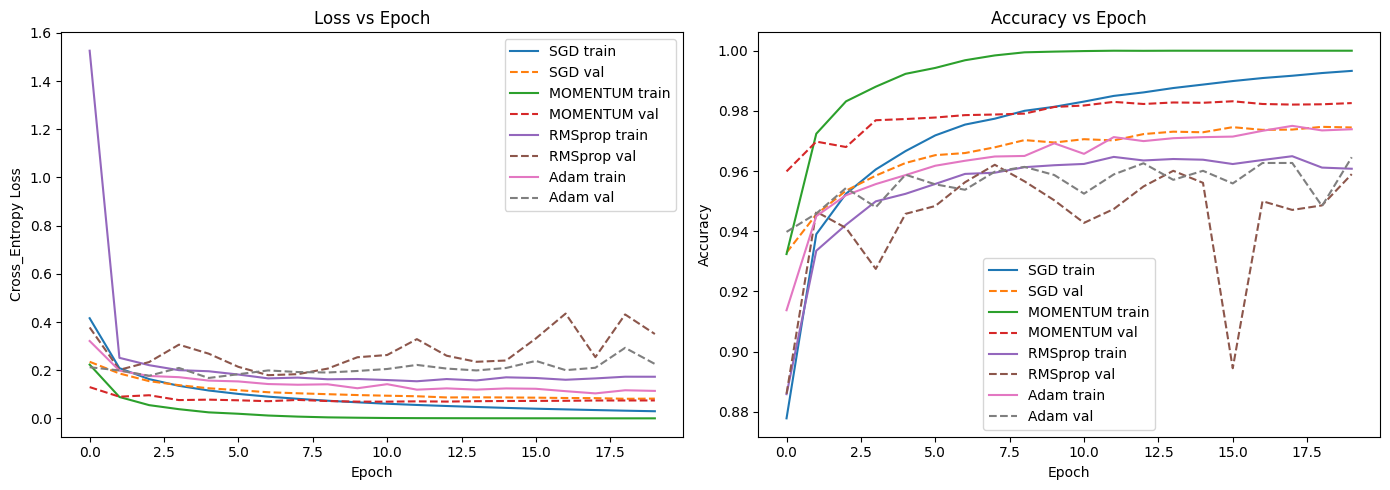

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for opt_name, h in all_histories.items():
    axes[0].plot(h["train_loss"], label=f"{opt_name} train")
    axes[0].plot(h["val_loss"], linestyle="--", label=f"{opt_name} val")

axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross_Entropy Loss")
axes[0].legend()

for opt_name, h in all_histories.items():
    axes[1].plot(h["train_acc"], label=f"{opt_name} train")
    axes[1].plot(h["val_acc"], linestyle="--", label=f"{opt_name} val")

axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Results Summary



TODO